In [1]:
!pip install scikit-learn
from sklearn.model_selection import train_test_split
import requests
import pandas as pd
from tqdm import tqdm
import tmdbdata as td
import random

Récupération des données 

In [2]:
df=td.get_movies_info([random.randint(100, 10000) for _ in range(10)],headers=td.headers)

getting movie info


100%|██████████| 10/10 [00:02<00:00,  4.67it/s]


In [5]:
df

,success,status_code,status_message,adult,backdrop_path,belongs_to_collection,budget,genres,homepage,id,...,status,tagline,title,video,vote_average,vote_count,belongs_to_collection.id,belongs_to_collection.name,belongs_to_collection.poster_path,belongs_to_collection.backdrop_path
0,False,34.0,The resource you requested could not be found.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,False,34.0,The resource you requested could not be found.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,False,34.0,The resource you requested could not be found.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,False,/u7pSF7fAo2mCBOz1d5QPIK9yf2v.jpg,None,0.0,"[{'id': 28, 'name': 'Action'}, {'id': 35, 'nam...",,8833.0,...,Released,,Double Trouble,False,7.000,515.0,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,False,/qwGkQpQbDXuHDOq909RQmJPENwN.jpg,None,70000000.0,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",,8427.0,...,Released,Attitude meets espionage.,I Spy,False,5.400,932.0,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,False,None,None,0.0,"[{'id': 53, 'name': 'Thriller'}, {'id': 80, 'n...",,5501.0,...,Released,Her first case as a rookie detective is about ...,Intimate Nights,False,6.500,3.0,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,False,/jY9ef5nqY4xIIMu3yzW3qamUCoi.jpg,NaN,38000000.0,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam...",https://www.uphe.com/movies/the-fast-and-the-f...,9799.0,...,Released,"If you have what it takes, you can have it all.",The Fast and the Furious,False,6.985,9967.0,9485.0,The Fast and the Furious Collection,/zQdytnqfsWKJlqazqfMBL2L7aql.jpg,/56h4DCt0ogIRI7B71xD5iA5hES1.jpg
7,False,34.0,The resource you requested could not be found.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,False,/r6Ai2I1F4rWlNo5SzAUzQ4hWGjC.jpg,None,350000.0,"[{'id': 99, 'name': 'Documentary'}]",http://www.kids-with-cameras.org/bornintobroth...,1392.0,...,Released,,Born Into Brothels: Calcutta's Red Light Kids,False,6.854,223.0,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,False,/axxpynbxypsnoo5pE8BWLyJ0aXK.jpg,NaN,777000.0,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",,838.0,...,Released,Where were you in '62?,American Graffiti,False,7.000,1422.0,124950.0,American Graffiti Collection,/gSvqziPNizBJA9LSxaDzTAkurTl.jpg,/fkQH8aHqLpdDYXyCXdqRgYOhsoN.jpg


In [ ]:
df1=df[df["status_message"].isna()]
df1=td.drop_useless_info(df1)
df1 = df1.dropna(subset=['genres'])
df1=td.keep_main_genre(df1)
df1 = df1.drop(columns=["success", "status_code", "status_message"])
df1=td.keep_main_genre(df1)
df1=td.full_poster_path(df1)
df1.head()
df1.describe()
df1.shape


KeyError: 'genres'

In [6]:
df1.head()

,budget,id,overview,popularity,poster_path,release_date,revenue,runtime,title,vote_average,vote_count,main_genre_id,main_genre_name
0,12000000.0,9584.0,"Trucker Rubber Duck and his buddies Pig Pen, W...",28.821,/fhjLa7wysN5kII0AaWmbM6SbUpL.jpg,1978-06-27,45000000.0,110.0,Convoy,6.300,368.0,28,Action
1,4000000.0,627.0,Heroin addict Mark Renton stumbles through bad...,33.347,/fCNd4D6I6n1xZKUbZI6Hco28EQ0.jpg,1996-02-23,72000000.0,94.0,Trainspotting,8.000,9618.0,18,Drama
2,0.0,9033.0,"In this direct-to-video sequel, Gabriel return...",10.389,/paHyRgF3uBMvK3i4YRjJ9wwFxbH.jpg,1998-01-20,0.0,83.0,The Prophecy II,6.000,207.0,27,Horror
7,0.0,8092.0,When a son and mother move to Seattle in hopes...,15.820,/hmSIhx180f0ADcpaQisVXYRB6Fr.jpg,1993-04-09,4104962.0,115.0,This Boy's Life,7.132,979.0,18,Drama


On remarque que qu'il y'a des données où le budget n'est pas renseigné, en effet on a min budget égal à 0.

In [31]:
df1=df1.loc[df1["budget"]!=0] # on supprime les lignes où le budget n'est pas renseigné, l'imputation est possible par le budget moyen, pour le moment on fait le choix de ne pas imputer
df1=df1.loc[df1["revenue"]!=0]
df1.shape

(45, 16)

On va créer une colonne comptant le nombre de mots caractères dans le synopsis 

In [32]:
df1["overview_count"]=df1["overview"].map(len)
df1.head()
df1.shape

(45, 17)

Nous allons encoder les genres pour la regression linéaire : méthode one hot encoding

In [33]:
df1["main_genre_name"].unique() 

array(['Animation', 'Action', 'Drama', 'Comedy', 'Romance', 'Horror',
       'Mystery', 'Adventure', 'Thriller', 'Crime', 'Science Fiction',
       'Fantasy'], dtype=object)

In [49]:
#Méthode : OneHotEncoder
for genre in df1["main_genre_name"].unique() :
    df1["main_genre_name"+"_"+str(genre)] = (df1["main_genre_name"] == genre).astype(int) 
df1.shape
df1.head()

KeyError: 'main_genre_name'

Nous allons essayer de prédire la note c'est à dire vote_average à partir des variables suivantes :

In [35]:
df1["main_genre_name"].unique()
L=[]
for i in df1["main_genre_name"].unique() : 
    L.append("main_genre_name"+"_"+str(i))
print(L)

var_explicative=["id","vote_average","budget","runtime","overview_count","revenue"]
var_explicative.extend(L)
df1=df1.loc[:,var_explicative]
df1.head(1)


['main_genre_name_Animation', 'main_genre_name_Action', 'main_genre_name_Drama', 'main_genre_name_Comedy', 'main_genre_name_Romance', 'main_genre_name_Horror', 'main_genre_name_Mystery', 'main_genre_name_Adventure', 'main_genre_name_Thriller', 'main_genre_name_Crime', 'main_genre_name_Science Fiction', 'main_genre_name_Fantasy']


,id,vote_average,budget,runtime,overview_count,revenue,main_genre_name_Animation,main_genre_name_Action,main_genre_name_Drama,main_genre_name_Comedy,main_genre_name_Romance,main_genre_name_Horror,main_genre_name_Mystery,main_genre_name_Adventure,main_genre_name_Thriller,main_genre_name_Crime,main_genre_name_Science Fiction,main_genre_name_Fantasy
10,3170.0,7.009,858000.0,70.0,114,267447150.0,1,0,0,0,0,0,0,0,0,0,0,0


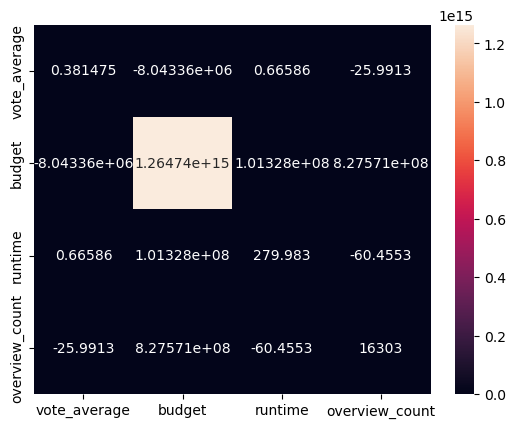

In [36]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

cov = np.cov(df1.loc[:,["vote_average","budget","runtime","overview_count"]].T, bias=True)
labs = ['vote_average', 'budget', 'runtime',"overview_count"]

sns.heatmap(cov, annot=True, fmt='g', xticklabels=labs, yticklabels=labs)
plt.show()


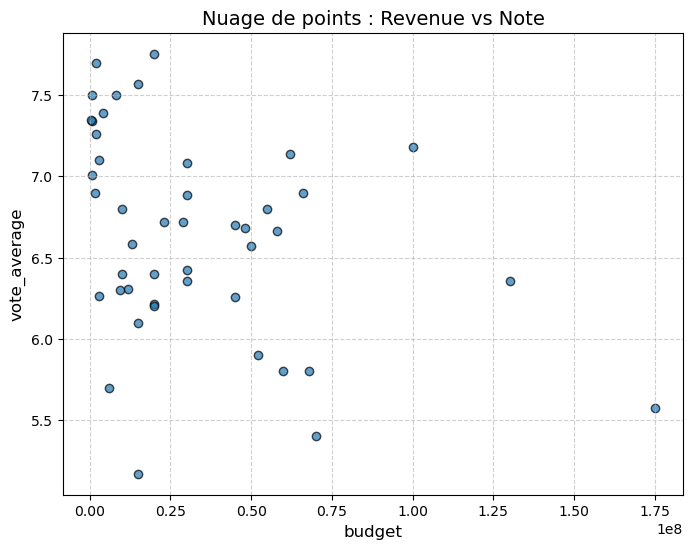

In [37]:
import matplotlib.pyplot as plt

# Tracer le nuage de points
plt.figure(figsize=(8, 6))
plt.scatter(df1['budget'], df1['vote_average'], alpha=0.7, edgecolor='k')

# Ajouter des labels et un titre
plt.title("Nuage de points : Revenue vs Note", fontsize=14)
plt.xlabel("budget", fontsize=12)
plt.ylabel("vote_average", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Afficher le graphique
plt.show()

/tmp/ipykernel_30900/712210021.py:1: DeprecationWarning: bias and ddof have no effect and are deprecated
  corr = np.corrcoef(df1.loc[:,["vote_average","budget","runtime","overview_count","revenue"]].T, bias=True)


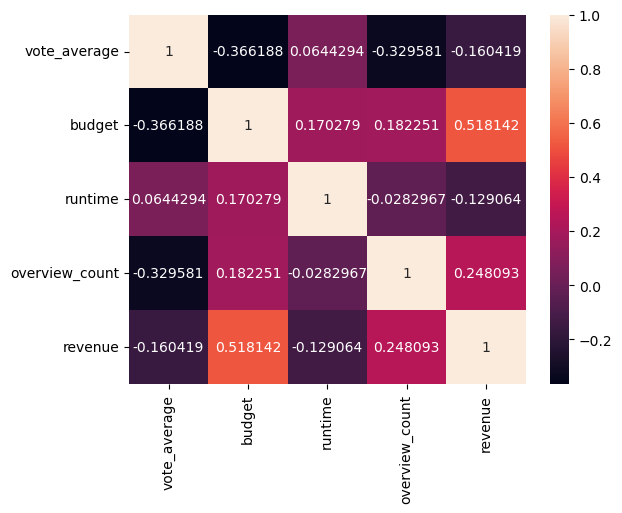

In [38]:


corr = np.corrcoef(df1.loc[:,["vote_average","budget","runtime","overview_count","revenue"]].T, bias=True)
labs = ['vote_average', 'budget', 'runtime',"overview_count","revenue"]

sns.heatmap(corr, annot=True, fmt='g', xticklabels=labs, yticklabels=labs)
plt.show()

Si on rajoute main_genre_name_Drama :

/tmp/ipykernel_30900/1422207673.py:1: DeprecationWarning: bias and ddof have no effect and are deprecated
  corr = np.corrcoef(df1.loc[:,["vote_average","budget","runtime","overview_count","revenue","main_genre_name_Drama"]].T, bias=True)


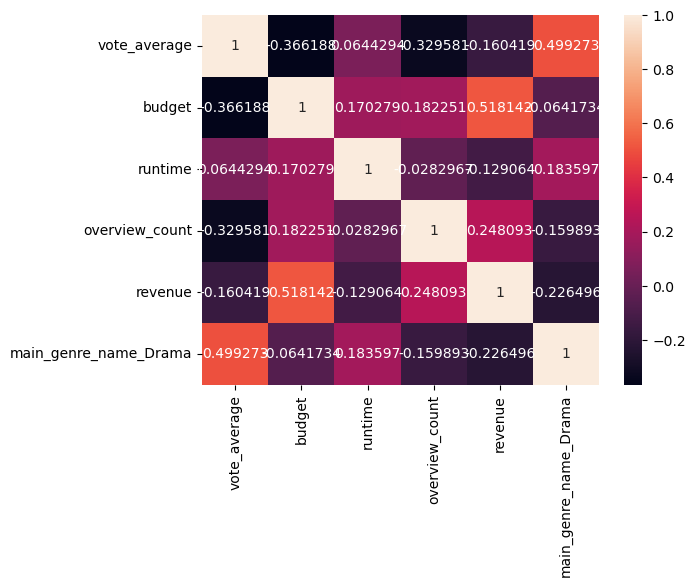

In [39]:
corr = np.corrcoef(df1.loc[:,["vote_average","budget","runtime","overview_count","revenue","main_genre_name_Drama"]].T, bias=True)
labs = ['vote_average', 'budget', 'runtime',"overview_count","revenue","main_genre_name_Drama"]

sns.heatmap(corr, annot=True, fmt='g', xticklabels=labs, yticklabels=labs)
plt.show()

Normalisation et Standardisation des données : pas nécessaire dans la regression linéaire car le modèle ne sélectionne pas en fonction des poids, ce qui arrive dans les modèles de clustering. 

Régression linéaire :

In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
#X=df1.loc[:,~df1.columns.isin(['id', 'vote_average']) ]
X=df1.loc[:,["budget","runtime","overview_count","revenue"] ]
Y=df1[["vote_average"]]
X.head()
Y.head()

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1) #80% de train
#X_train.shape
#X_test.shape

# Initialiser le modèle de régression linéaire
model = LinearRegression()

# Entraîner le modèle avec l'ensemble d'entraînement
model.fit(X_train, Y_train)

# Prédire les résultats sur l'ensemble de test
Y_pred = model.predict(X_test)

# Afficher les coefficients de la régression linéaire
print("Coefficients de la régression linéaire :", model.coef_)
print("Ordonnée à l'origine (intercept) :", model.intercept_)

# Évaluer la performance du modèle
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print(f"Erreur quadratique moyenne (MSE) : {mse}")
print(f"Score R2 : {r2}")

Coefficients de la régression linéaire : [[-7.39509406e-09  5.22664137e-03 -1.02071158e-03  8.67248657e-10]]
Ordonnée à l'origine (intercept) : [6.53547927]
Erreur quadratique moyenne (MSE) : 0.2771151356563296
Score R2 : 0.20255041109337224


Distinguer les covariables ayant réellement un impact sur Y : (tests multiples de niveau 5%, rejet de H0 à tort au niv 5%) 

In [41]:
import statsmodels.api as sm


# Ajouter une constante à X pour inclure l'intercept dans le modèle
X = sm.add_constant(X)

# Créer le modèle de régression linéaire
model = sm.OLS(Y, X).fit()  # OLS = Ordinary Least Squares (régression linéaire)

# Obtenir les résultats du modèle
summary = model.summary()

# Afficher le résumé qui contient les statistiques t de chaque covariable
print(summary)
r2 = model.rsquared
print(f"R² : {r2}")
# la différence de R2 entre statmodel et sklearn vient du fait qu'on entraine nos données sur 100% des données sur statmodel vs 80% sur sklearn 

#Afficher la T-stat pour runtime
T_stat_runtime=model.tvalues["runtime"]
print(T_stat_runtime)

#Zone de rejet de niveau 5% pour notre test d'hypothèse : 
from scipy.stats import norm
quantile = norm.ppf(1-5/200, loc=0, scale=1)
if T_stat_runtime >= quantile or T_stat_runtime <= - quantile : 
    print("le coef théorique devant runtime est trop proche de 0, on le rejete")
else: 
    print("on conserve la variable explicative runtime")


                            OLS Regression Results                            
Dep. Variable:           vote_average   R-squared:                       0.232
Model:                            OLS   Adj. R-squared:                  0.155
Method:                 Least Squares   F-statistic:                     3.017
Date:                Tue, 10 Dec 2024   Prob (F-statistic):             0.0289
Time:                        09:37:14   Log-Likelihood:                -36.235
No. Observations:                  45   AIC:                             82.47
Df Residuals:                      40   BIC:                             91.50
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              6.5895      0.623     10.

In [42]:
# Ajouter une constante à X pour inclure l'intercept dans le modèle
X = sm.add_constant(X)

# Créer le modèle de régression linéaire
model = sm.OLS(Y, X).fit(cov_type='HC3')  # Utilisation d'erreurs standard robustes (HC3)

# Obtenir les résultats du modèle
summary = model.summary()

# Afficher le résumé qui contient les statistiques t de chaque covariable
print(summary)

                            OLS Regression Results                            
Dep. Variable:           vote_average   R-squared:                       0.232
Model:                            OLS   Adj. R-squared:                  0.155
Method:                 Least Squares   F-statistic:                     3.130
Date:                Tue, 10 Dec 2024   Prob (F-statistic):             0.0249
Time:                        09:37:14   Log-Likelihood:                -36.235
No. Observations:                  45   AIC:                             82.47
Df Residuals:                      40   BIC:                             91.50
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              6.5895      0.534     12.

In [43]:
# Généralisation : 
var_explicative_significative_au_niv_5=[]
X.columns
for var_explicative in X.columns:
    if model.tvalues[var_explicative] >= quantile or model.tvalues[var_explicative] <= - quantile : 
        print("le coef théorique devant ", var_explicative , "est trop proche de 0, on le rejete")
    else: 
        print("on conserve la variable explicative:",var_explicative)
        var_explicative_significative_au_niv_5.append(var_explicative)
print(quantile)
print(var_explicative_significative_au_niv_5)
    

le coef théorique devant  const est trop proche de 0, on le rejete
le coef théorique devant  budget est trop proche de 0, on le rejete
on conserve la variable explicative: runtime
on conserve la variable explicative: overview_count
on conserve la variable explicative: revenue
1.959963984540054
['runtime', 'overview_count', 'revenue']


In [44]:
from itertools import combinations

def generate_combinations(elements, k):
    """
    Génère toutes les combinaisons de k éléments dans une liste donnée.
    
    :param elements: Liste d'éléments (par exemple, une liste de variables).
    :param k: Nombre d'éléments à sélectionner.
    :return: Liste de tuples, chaque tuple représentant une combinaison.
    """
    return list(combinations(elements, k))



1
('runtime',)
('overview_count',)
('revenue',)
2
('runtime', 'overview_count')
('runtime', 'revenue')
('overview_count', 'revenue')
3
('runtime', 'overview_count', 'revenue')


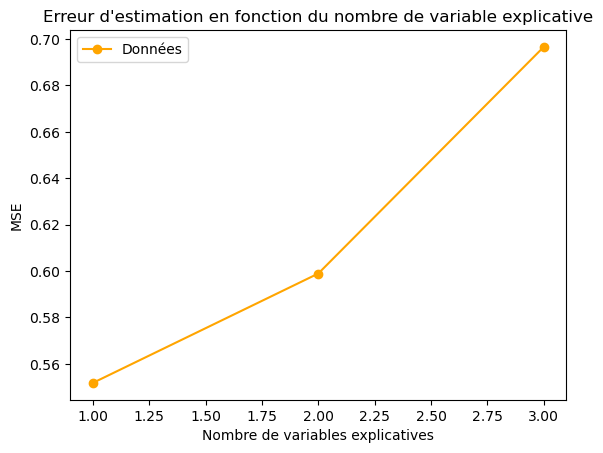

In [45]:
X=X.loc[:,var_explicative_significative_au_niv_5[:7]] #On peut enlever [:7], ici sur nos données ca explose pour une certaines vraibles il va donc falloir l'enlever
X.head()
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42) 
a=[]
b=[]
for i in range(1,len(var_explicative_significative_au_niv_5[:7])+1): #On peut enlever [:7]
    print(i)
    combinations_list = generate_combinations(var_explicative_significative_au_niv_5[:7], i) #On peut enlever [:7]
    L=[]
    for comb in combinations_list: 
        print(comb)
        # Initialiser le modèle de régression linéaire
        model = LinearRegression()

        # Entraîner le modèle avec l'ensemble d'entraînement
        model.fit(X_train.loc[:,comb], Y_train)

        # Prédire les résultats sur l'ensemble de test
        Y_pred = model.predict(X_test.loc[:,comb])

        # Évaluer la performance du modèle
        mse = mean_squared_error(Y_test, Y_pred)
        L.append(mse)
    a.append(i)
    b.append(min(L))

import matplotlib.pyplot as plt

# Créer un graphique avec une couleur personnalisée
plt.plot(a, b, color='orange', marker='o', linestyle='-', label='Données')  
# Ajouter des titres et des légendes
plt.title("Erreur d'estimation en fonction du nombre de variable explicative")
plt.xlabel("Nombre de variables explicatives")
plt.ylabel("MSE")
plt.legend()  # Affiche la légende

# Afficher le graphe
plt.show()

1
('runtime',)
('overview_count',)
('revenue',)
2
('runtime', 'overview_count')
('runtime', 'revenue')
('overview_count', 'revenue')
3
('runtime', 'overview_count', 'revenue')


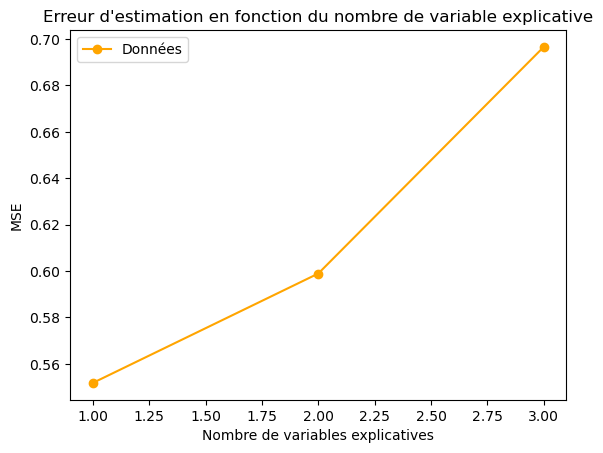

In [46]:
X=X.loc[:,var_explicative_significative_au_niv_5] #On peut enlever [:7], ici sur nos données ca explose pour une certaines vraibles il va donc falloir l'enlever
X.head()
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42) 
a=[]
b=[]
for i in range(1,len(var_explicative_significative_au_niv_5)+1): #On peut enlever [:7]
    print(i)
    combinations_list = generate_combinations(var_explicative_significative_au_niv_5, i) #On peut enlever [:7]
    L=[]
    for comb in combinations_list: 
        print(comb)
        # Initialiser le modèle de régression linéaire
        model = LinearRegression()

        # Entraîner le modèle avec l'ensemble d'entraînement
        model.fit(X_train.loc[:,comb], Y_train)

        # Prédire les résultats sur l'ensemble de test
        Y_pred = model.predict(X_test.loc[:,comb])

        # Évaluer la performance du modèle
        mse = mean_squared_error(Y_test, Y_pred)
        L.append(mse)
    a.append(i)
    b.append(min(L))

import matplotlib.pyplot as plt

# Créer un graphique avec une couleur personnalisée
plt.plot(a, b, color='orange', marker='o', linestyle='-', label='Données')  
# Ajouter des titres et des légendes
plt.title("Erreur d'estimation en fonction du nombre de variable explicative")
plt.xlabel("Nombre de variables explicatives")
plt.ylabel("MSE")
plt.legend()  # Affiche la légende

# Afficher le graphe
plt.show()

Il est donc clair qu'il n'est pas favorable d'ajouter toutes les variables explicatives. 

Var optimum : 

In [47]:
X=X.loc[:,var_explicative_significative_au_niv_5] 
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42) 
comb_optimum=[]
mse_min=1
for i in range(1,len(var_explicative_significative_au_niv_5)+1): 
    combinations_list = generate_combinations(var_explicative_significative_au_niv_5, i) 
    for comb in combinations_list: 
        # Initialiser le modèle de régression linéaire
        model = LinearRegression()
        # Entraîner le modèle avec l'ensemble d'entraînement
        model.fit(X_train.loc[:,comb], Y_train)
        # Prédire les résultats sur l'ensemble de test
        Y_pred = model.predict(X_test.loc[:,comb])
        # Évaluer la performance du modèle
        mse = mean_squared_error(Y_test, Y_pred)
        if mse < mse_min:
            mse_min=mse
            comb_optimum=comb

print("Le mse min est : ",mse_min," et les variables explicatives permettant de l'atteindre sont : ",comb_optimum)

Le mse min est :  0.5517741604016907  et les variables explicatives permettant de l'atteindre sont :  ('revenue',)


Méthode Lasso :